<a href="https://colab.research.google.com/github/natitedros/WAVN-agentic-navigation/blob/main/poc_tests/blip2_test_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 3: Testing BLIP-2 on grouding DINO outupt images

Note: BLIP-2 needs most of the free GPU's memory.

This notebook tests the two jobs BLIP-2 has in the perception agent:
- **Describing** each object Grounding DINO found (the shared landmark descriptions).
- **Answering** the path-finding agent's clarifying questions.

## 1. Install and check the GPU

In [1]:
!pip install -q -U transformers accelerate bitsandbytes

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. Set Runtime -> Change runtime type -> T4 GPU, then run again.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 17.7 MB/s eta 0:00:00
GPU available: True
GPU: Tesla T4
GPU memory: 15.6 GB


## 2. Connect Google Drive and find the Step 2 results

Use the **same** `IMAGE_FOLDER` as in the Grounding DINO notebook. This notebook reads the detections that notebook saved.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd

IMAGE_FOLDER = "/content/drive/MyDrive/tartanground/open_images_sample"

DINO_RESULTS = os.path.join(IMAGE_FOLDER, "grounding_dino_results_openimages")
DETECTIONS_CSV = os.path.join(DINO_RESULTS, "detections_general_prompts.csv")
RESULTS_FOLDER = os.path.join(IMAGE_FOLDER, "blip2_results")
os.makedirs(RESULTS_FOLDER, exist_ok=True)

IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")
image_files = sorted(f for f in os.listdir(IMAGE_FOLDER) if f.lower().endswith(IMAGE_EXTENSIONS))
print(f"Found {len(image_files)} images")

if os.path.exists(DETECTIONS_CSV):
    detections = pd.read_csv(DETECTIONS_CSV)
    detections = detections[detections["label"].notna()].reset_index(drop=True)
    print(f"Found {len(detections)} detections from Step 2")
else:
    detections = pd.DataFrame()
    print("No Step 2 detections found. Sections 6 and 7 will be skipped;")
    print("run the Grounding DINO notebook first, or check IMAGE_FOLDER.")

Mounted at /content/drive
Found 20 images
Found 63 detections from Step 2


## 3. Load BLIP-2

The first run downloads about 15 GB from Hugging Face, so it takes several minutes. Later runs in the same session are fast.

- Half precision (`float16`) uses roughly 8 GB of the T4's 15 GB.
- If the session **crashes or runs out of memory** while loading, set `LOAD_IN_8BIT = True`, restart the runtime, and run again. It uses about half the memory and is a bit slower.

In [3]:
from transformers import Blip2Processor, Blip2ForConditionalGeneration, BitsAndBytesConfig

MODEL_ID = "Salesforce/blip2-opt-2.7b"
LOAD_IN_8BIT = False        # set True if loading runs out of memory

processor = Blip2Processor.from_pretrained(MODEL_ID)

load_kwargs = {"device_map": "auto"}
if LOAD_IN_8BIT:
    load_kwargs["quantization_config"] = BitsAndBytesConfig(load_in_8bit=True)

try:
    model = Blip2ForConditionalGeneration.from_pretrained(MODEL_ID, dtype=torch.float16, **load_kwargs)
except TypeError:   # older transformers versions use the name torch_dtype
    model = Blip2ForConditionalGeneration.from_pretrained(MODEL_ID, torch_dtype=torch.float16, **load_kwargs)
model.eval()

print("Model loaded")
print(f"GPU memory in use: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/882 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded
GPU memory in use: 7.7 GB


## 4. Helper functions

- `caption(image)`: a short description of the image.
- `ask(image, question)`: an answer to a question about the image.

Both also return a **rough confidence** (0 to 1): how sure the model was about the words it chose. It is not a guarantee of correctness. Part of this test is finding out whether low confidence actually lines up with wrong answers.

In [4]:
import time
import math
from PIL import Image
import matplotlib.pyplot as plt

MAX_NEW_TOKENS = 40


def load_image(fname):
    return Image.open(os.path.join(IMAGE_FOLDER, fname)).convert("RGB")


def _generate(image, prompt=None):
    """Run BLIP-2 once. Returns (text, confidence, seconds)."""
    if prompt is None:
        inputs = processor(images=image, return_tensors="pt")
    else:
        inputs = processor(images=image, text=prompt, return_tensors="pt")
    inputs = inputs.to(model.device, torch.float16)

    torch.cuda.synchronize()
    start = time.perf_counter()
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            num_beams=1,
            output_scores=True,
            return_dict_in_generate=True,
        )
    torch.cuda.synchronize()
    seconds = time.perf_counter() - start

    # Keep only the newly generated words (some versions also return the prompt).
    n_new = len(out.scores)
    new_tokens = out.sequences[0, -n_new:]
    text = processor.decode(new_tokens, skip_special_tokens=True)
    text = text.split("\n")[0].split("Question:")[0].strip()

    # Rough confidence: average probability of the generated words.
    log_probs = model.compute_transition_scores(out.sequences, out.scores, normalize_logits=True)[0]
    log_probs = log_probs[torch.isfinite(log_probs)]
    confidence = math.exp(log_probs.float().mean().item()) if len(log_probs) else 0.0

    return text, round(confidence, 3), seconds


def caption(image):
    return _generate(image)


def ask(image, question):
    return _generate(image, f"Question: {question} Answer:")

## 5. Try one full image

Caption:  a silver car   (confidence 0.33, 201 ms)
Q: What objects are in this image?
A: A car, a woman, and a dog   (confidence 0.40, 316 ms)


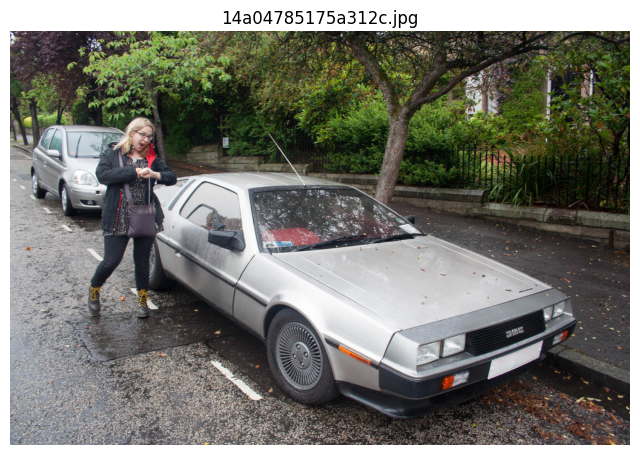

In [5]:
fname = image_files[0]
image = load_image(fname)

caption(image)   # warm-up run (the first run is always slow)

text, conf, seconds = caption(image)
print(f"Caption:  {text}   (confidence {conf:.2f}, {seconds * 1000:.0f} ms)")

question = "What objects are in this image?"            # <-- EDIT if you like
text, conf, seconds = ask(image, question)
print(f"Q: {question}")
print(f"A: {text}   (confidence {conf:.2f}, {seconds * 1000:.0f} ms)")

plt.figure(figsize=(8, 6)); plt.imshow(image); plt.axis("off"); plt.title(fname); plt.show()

## 6. Describe every object Grounding DINO found

This is what the perception agent does: crop each detected object and describe the crop.

- `CROP_PADDING` widens each crop a little so nearby things stay visible. With `0.0` the model only sees the object itself and cannot say "next to a fence". Try `0.0`, `0.15` and `0.4` and compare the descriptions.
- `MIN_CROP_SIZE` skips objects that are too small to describe (BLIP-2 shrinks every image to 224×224 pixels).

For each object you get two descriptions:
- **caption**: BLIP-2's free description of the crop.
- **guided**: a description where BLIP-2 is told what the object is and asked for its color and surroundings.

In [6]:
import ast

CROP_PADDING = 0.4     # <-- EDIT to compare (0.0 = tight crop)
MIN_CROP_SIZE = 32      # pixels


def crop_object(image, box, padding=CROP_PADDING):
    x0, y0, x1, y1 = box
    pad_x, pad_y = (x1 - x0) * padding, (y1 - y0) * padding
    return image.crop((max(0, x0 - pad_x), max(0, y0 - pad_y),
                       min(image.width, x1 + pad_x), min(image.height, y1 + pad_y)))


def clean_label(label):
    label = str(label).lower().strip()
    for article in ("a ", "an ", "the "):
        if label.startswith(article):
            label = label[len(article):]
    return label


rows, crops = [], []
skipped = 0

for _, det in detections.iterrows():
    box = ast.literal_eval(det["box"]) if isinstance(det["box"], str) else det["box"]
    if (box[2] - box[0]) < MIN_CROP_SIZE or (box[3] - box[1]) < MIN_CROP_SIZE:
        skipped += 1
        continue

    image = load_image(det["image"])
    crop = crop_object(image, box)
    label = clean_label(det["label"])

    cap_text, cap_conf, cap_time = caption(crop)
    guided_text, guided_conf, guided_time = ask(
        crop, f"Describe the {label} in this image, including its color and what is next to it.")

    rows.append({
        "image": det["image"], "detector_label": label, "detector_score": det["score"], "box": box,
        "caption": cap_text, "caption_confidence": cap_conf,
        "guided": guided_text, "guided_confidence": guided_conf,
        "time_ms": round((cap_time + guided_time) * 1000, 1),
    })
    crops.append(crop)

captions_df = pd.DataFrame(rows)
if len(captions_df):
    out_path = os.path.join(RESULTS_FOLDER, f"object_descriptions_padding_{CROP_PADDING}.csv")
    captions_df.to_csv(out_path, index=False)
    print(f"Described {len(captions_df)} objects ({skipped} skipped as too small)")
    print(f"Average time per object (both descriptions): {captions_df['time_ms'].mean():.0f} ms")
    print("Saved to", out_path)
    display(captions_df[["image", "detector_label", "caption", "caption_confidence",
                         "guided", "guided_confidence"]].head(20))
else:
    print("No detections to describe.")

Described 44 objects (19 skipped as too small)
Average time per object (both descriptions): 631 ms
Saved to /content/drive/MyDrive/tartanground/open_images_sample/blip2_results/object_descriptions_padding_0.4.csv


,image,detector_label,caption,caption_confidence,guided,guided_confidence
0,14a04785175a312c.jpg,girl person woman,a woman standing next to a car that has a flat...,0.484,The girl person woman in this image is standin...,0.389
1,14a04785175a312c.jpg,car,a woman standing next to a car with a umbrella,0.406,A woman is standing next to a car with a woman...,0.265
2,14a04785175a312c.jpg,tire wheel,a silver car parked on the side of the road,0.578,The tire wheel is a silver wheel with a black rim,0.269
3,14a04785175a312c.jpg,land vehicle,a silver car,0.341,A silver car,0.273
4,14a04785175a312c.jpg,human hair human head,a woman holding a dog,0.346,The woman is wearing a black jacket,0.290
5,1beea2712bf5a333.jpg,flag,a flag pole with a flag flying in the air,0.329,The flag is a white flag with a red cross on it,0.425
6,5de4dfef15a599cb.jpg,tire wheel,a white car with a black cat sitting on it,0.288,The tire wheel is a wheel that is used to turn...,0.277
7,5de4dfef15a599cb.jpg,building house,old white car in the grass,0.411,The building is a white building,0.294
8,5de4dfef15a599cb.jpg,sports equipment,a dog is sitting in a wheelbarrow,0.412,A wheelbarrow,0.388
9,65fa93cf7916e533.jpg,glasses sunglasses,a person holding a small animal in their hand,0.341,The glasses are a pair of sunglasses with a wh...,0.397


### Look at some crops next to their descriptions

Check each one by eye:
- Is the description **correct**?
- Does it mention details that would **tell this object apart** from a similar one (color, what is next to it)?
- Does it agree with what Grounding DINO called the object?

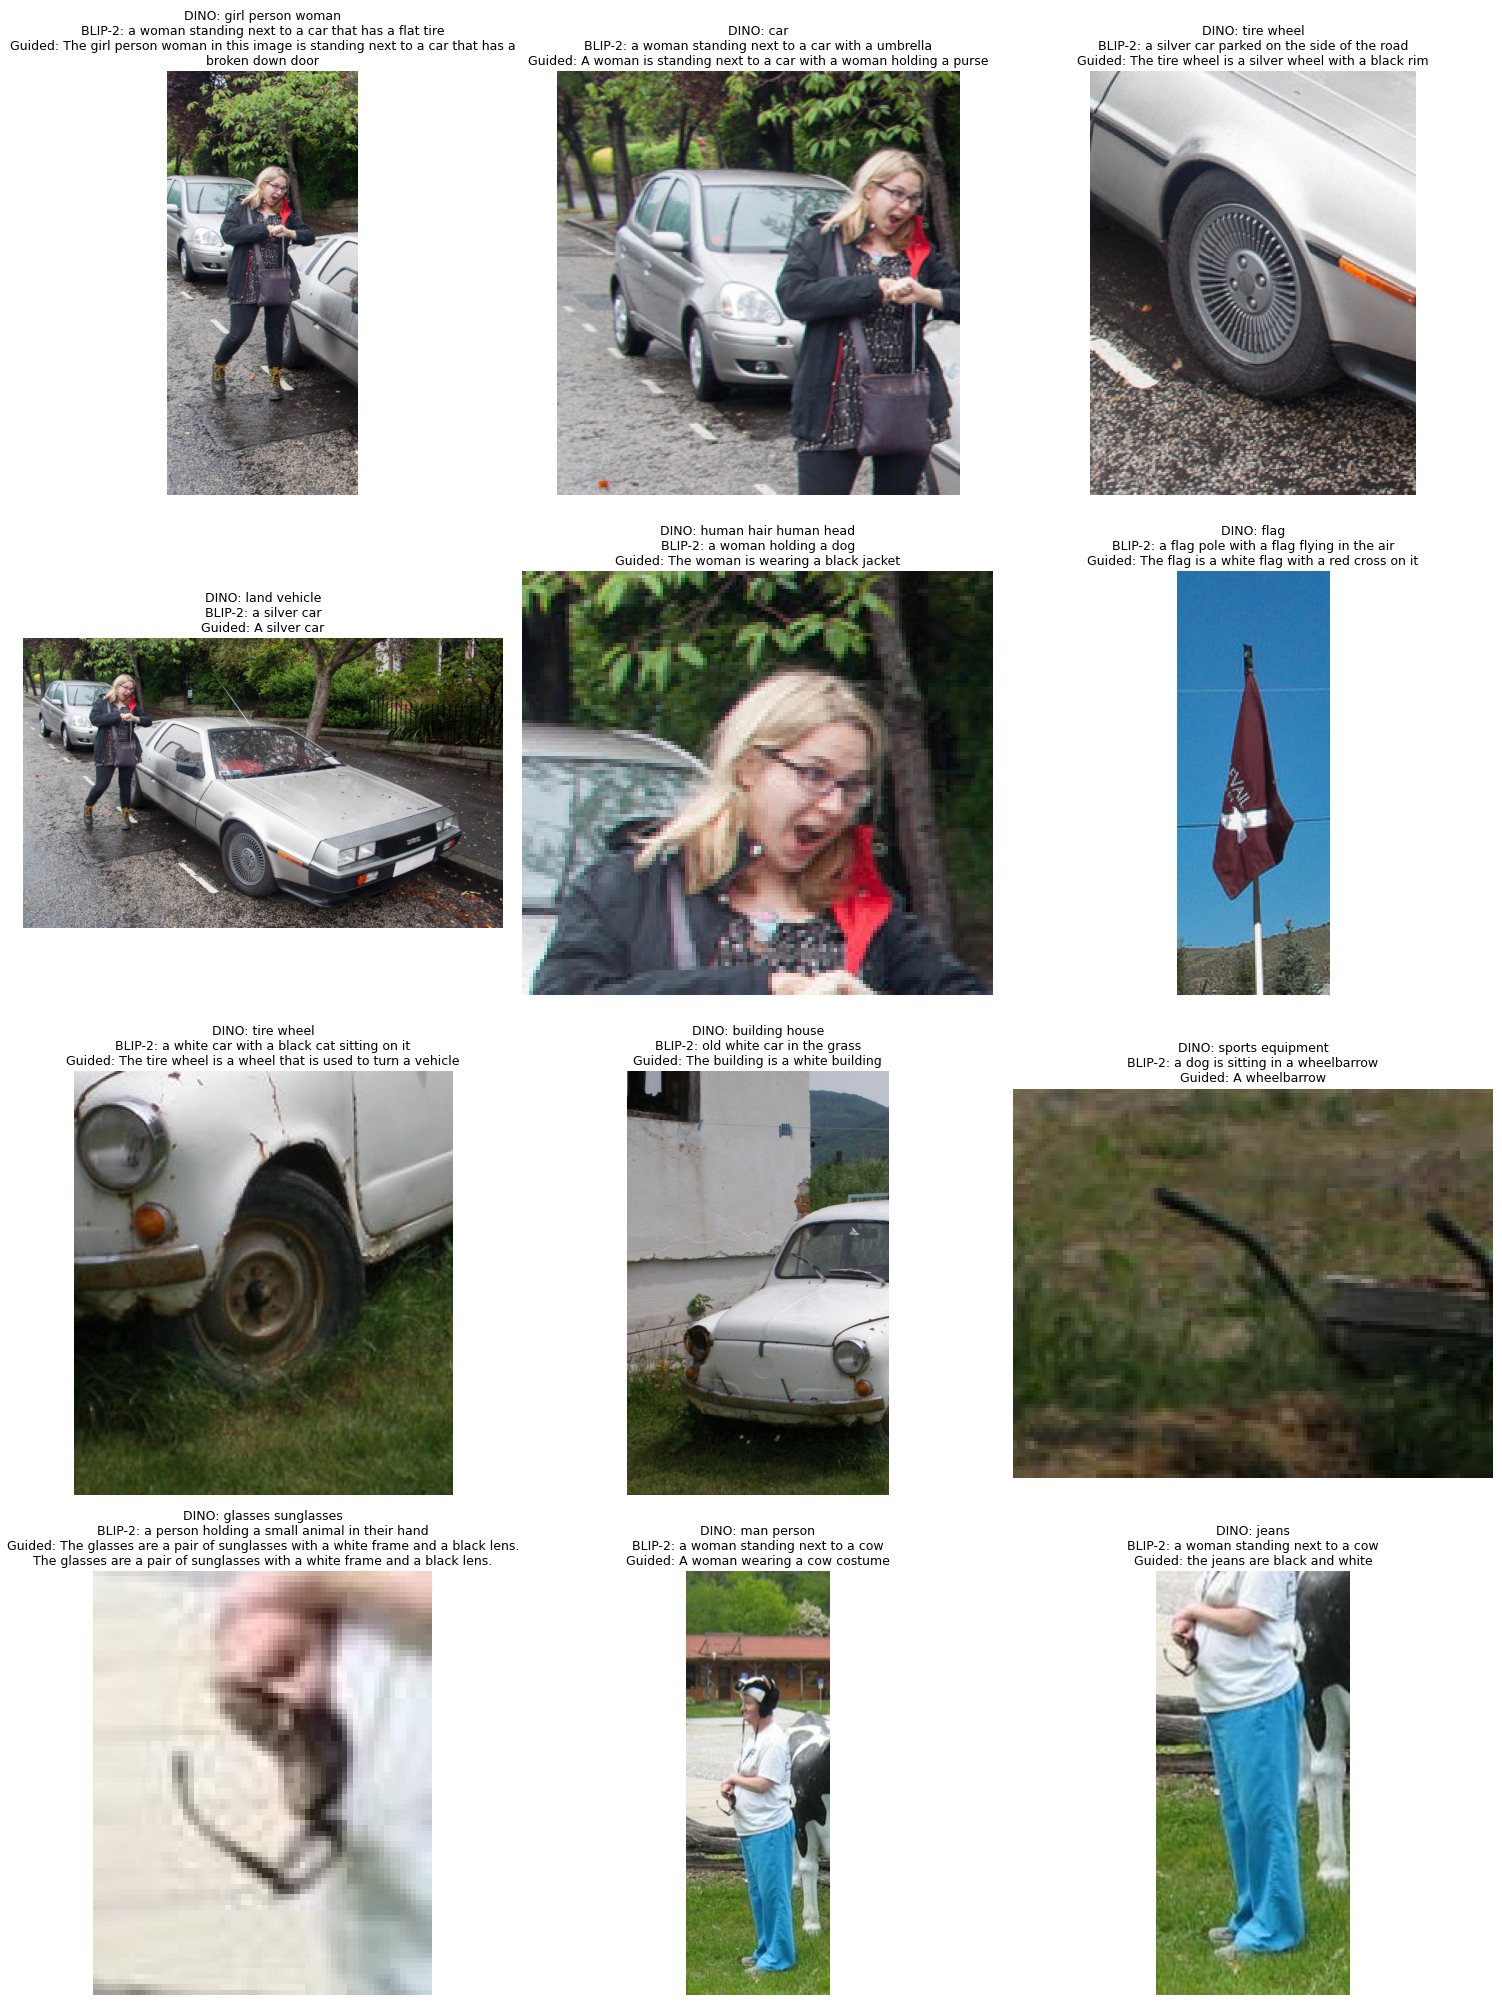

In [7]:
N_SHOW = 12

n = min(N_SHOW, len(crops))
if n:
    cols = 3
    n_rows = math.ceil(n / cols)
    fig, axes = plt.subplots(n_rows, cols, figsize=(15, 5 * n_rows))
    axes = list(axes.flat) if n > 1 else [axes]
    for ax in axes:
        ax.axis("off")
    for i in range(n):
        r = captions_df.iloc[i]
        axes[i].imshow(crops[i])
        axes[i].set_title(f'DINO: {r["detector_label"]}\nBLIP-2: {r["caption"]}\nGuided: {r["guided"]}',
                          fontsize=9, wrap=True)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_FOLDER, f"crops_with_descriptions_padding_{CROP_PADDING}.png"),
                bbox_inches="tight")
    plt.show()

## 7. Does BLIP-2 agree with Grounding DINO?

A quick automatic check: does the object name from Grounding DINO appear in BLIP-2's description? When the two models disagree, the detection or the description is probably wrong. That disagreement could later be a reason for the agent to lower its confidence.

In [8]:
if len(captions_df):
    def mentions_label(row):
        words = row["detector_label"].split()
        text = f'{row["caption"]} {row["guided"]}'.lower()
        return any(w in text for w in words)

    captions_df["blip2_agrees"] = captions_df.apply(mentions_label, axis=1)
    agree = captions_df["blip2_agrees"].mean()
    print(f"BLIP-2 mentions the detector's object in {100 * agree:.0f}% of descriptions")
    print("Average detector score when they agree:   ",
          round(captions_df.loc[captions_df["blip2_agrees"], "detector_score"].mean(), 2))
    print("Average detector score when they disagree:",
          round(captions_df.loc[~captions_df["blip2_agrees"], "detector_score"].mean(), 2))
    display(captions_df.loc[~captions_df["blip2_agrees"],
                            ["image", "detector_label", "detector_score", "caption", "guided"]])

BLIP-2 mentions the detector's object in 73% of descriptions
Average detector score when they agree:    0.63
Average detector score when they disagree: 0.59


,image,detector_label,detector_score,caption,guided
3,14a04785175a312c.jpg,land vehicle,0.573,a silver car,A silver car
4,14a04785175a312c.jpg,human hair human head,0.503,a woman holding a dog,The woman is wearing a black jacket
8,5de4dfef15a599cb.jpg,sports equipment,0.508,a dog is sitting in a wheelbarrow,A wheelbarrow
16,833212810ef0c76b.jpg,person,0.715,a jockey is riding a horse on a track,jockey joseph zayas
17,833212810ef0c76b.jpg,person,0.746,a jockey rides a horse on a track,jockey joseph zayas
21,833212810ef0c76b.jpg,person,0.654,two jockeys are riding horses on a track,jockey
28,9cb5c0880d992e51.jpg,person,0.561,a man wearing a blue shirt,A man wearing a blue shirt
29,9cb5c0880d992e51.jpg,person,0.576,a man wearing a blue shirt,A man wearing a blue shirt
30,9eed92c49db828f1.jpg,cattle,0.563,a couple of llamas standing in the dirt,The brown one is a llama
35,a0922dbd2cb47589.jpg,person,0.503,a man in a suit and tie standing next to a car,david cameron


## 8. Clarifying questions (what the path-finding agent will ask)

Fill in `QUESTION_TESTS` with questions about your own images and the answer you expect. Include:
- **Yes/no questions**, both ones where the answer is yes and ones where it is no.
- **"Which / what" questions**, like the ones that separate two similar objects.
- A few questions about things that are **not in the image**, to see whether the model makes things up.

The expected answer only needs to be a key word (for example `"yes"`, `"blue"`, `"left"`).

In [9]:
QUESTION_TESTS = [                                   # <-- EDIT: (image file, question, expected key word)
    ("65fa93cf7916e533.jpg", "Is teh person standing in the middle of the cows wearing a black shirt", "no"),
    # ("image_001.jpg", "Is the door next to a fence?", "yes"),
    ("5de4dfef15a599cb.jpg", "What color is the car next to the dog?", "white"),
    # ("image_001.jpg", "Is there a fire extinguisher in this image?", "no"),
    # ("04_png.png", "Is the mailbox on the left or the right side of the brown house?", "right"),
]

qa_rows = []
for fname, question, expected in QUESTION_TESTS:
    answer, conf, seconds = ask(load_image(fname), question)
    qa_rows.append({
        "image": fname, "question": question, "expected": expected, "answer": answer,
        "correct": expected.lower() in answer.lower(),
        "confidence": conf, "time_ms": round(seconds * 1000, 1),
    })

if qa_rows:
    qa_df = pd.DataFrame(qa_rows)
    qa_df.to_csv(os.path.join(RESULTS_FOLDER, "clarifying_question_tests.csv"), index=False)

    print(f"Correct: {qa_df['correct'].sum()} of {len(qa_df)} ({100 * qa_df['correct'].mean():.0f}%)")
    print(f"Average time per question: {qa_df['time_ms'].mean():.0f} ms")
    if qa_df["correct"].any():
        print(f"Average confidence, correct answers: {qa_df.loc[qa_df['correct'], 'confidence'].mean():.2f}")
    if (~qa_df["correct"]).any():
        print(f"Average confidence, wrong answers:   {qa_df.loc[~qa_df['correct'], 'confidence'].mean():.2f}")
    display(qa_df)
else:
    print("Fill in QUESTION_TESTS above first.")

Correct: 1 of 2 (50%)
Average time per question: 139 ms
Average confidence, correct answers: 0.40
Average confidence, wrong answers:   0.51


,image,question,expected,answer,correct,confidence,time_ms
0,65fa93cf7916e533.jpg,Is teh person standing in the middle of the co...,no,yes,False,0.511,153.7
1,5de4dfef15a599cb.jpg,What color is the car next to the dog?,white,White,True,0.398,125.1


## 9. What to write down

Copy these into your results spreadsheet:

| What | Where to find it |
|---|---|
| Are the object descriptions correct and detailed enough? | Section 6 (check by eye) |
| Which crop padding gives the most useful descriptions? | Re-run Section 6 with different `CROP_PADDING` |
| How often do BLIP-2 and Grounding DINO agree? | Section 7 |
| How many clarifying questions were answered correctly? | Section 8 |
| Is confidence higher for correct answers than wrong ones? | Section 8 |
| Time per description and per question | Sections 6 and 8 |
| GPU memory used | Cell below |

In [10]:
print(f"GPU memory in use:  {torch.cuda.memory_allocated() / 1e9:.1f} GB")
print(f"GPU memory at peak: {torch.cuda.max_memory_allocated() / 1e9:.1f} GB")
print("Results saved in:", RESULTS_FOLDER)

GPU memory in use:  7.7 GB
GPU memory at peak: 7.8 GB
Results saved in: /content/drive/MyDrive/tartanground/open_images_sample/blip2_results
